In [ ]:
DATA_DIR = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/Pharmaceutical and Biomedical Waste (PBW)" 

# Path to your trained .pth file
MODEL_PATH = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/best_model_full.pth"

# Path to the specific image you want to test right now
TEST_IMAGE_PATH = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/tweezers.jpg"


🧠 Model expects 13 classes.
✅ Exact match (13 vs 13). Using all entries including hidden files.
📂 Class List: ['(BT) Body Tissue or Organ', '(GE) Glass equipment-packaging 551', '(ME) Metal equipment -packaging', '(OW) Organic wastes', '(PE) Plastic equipment-packaging', '(PP) Paper equipment-packaging', '(SN) Syringe needles', '.DS_Store', 'Gauze', 'Gloves', 'Mask', 'Syringe', 'Tweezers']

🔄 Loading Model...
✅ Detected Full Model Object. Using directly.


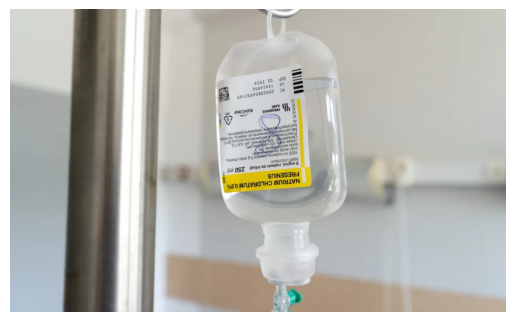

Prediction: (PE) Plastic equipment-packaging
Confidence: 97.94%


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/Pharmaceutical and Biomedical Waste (PBW)" 
MODEL_PATH = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/best_model_full.pth"
TEST_IMAGE_PATH = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/t3.webp"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. ALIGN CLASSES
# ==========================================
def get_classes_and_verify(data_dir, model_path):
    # Get all folders (including .DS_Store)
    all_entries = sorted(os.listdir(data_dir))
    
    # Load model to check how many neurons it has
    try:
        # Load the full model object
        loaded_object = torch.load(model_path, map_location=device, weights_only=False)
        
        # Check output neurons (for ViT it's typically heads.head.weight)
        if isinstance(loaded_object, nn.Module):
             # Access the final layer directly
            num_outputs = loaded_object.heads.head.out_features
            print(f"🧠 Model expects {num_outputs} classes.")
        else:
            # Fallback if it was a dict (unlikely given your error)
            num_outputs = len(all_entries)
            
    except Exception as e:
        print(f"⚠️ Warning during inspection: {e}")
        num_outputs = len(all_entries)

    # Filter logic
    if len(all_entries) == num_outputs:
        print(f"✅ Exact match (13 vs 13). Using all entries including hidden files.")
        return all_entries
    else:
        # If mismatch, try removing hidden files
        clean_entries = [x for x in all_entries if not x.startswith('.')]
        if len(clean_entries) == num_outputs:
            print(f"✅ Match found by removing hidden files ({num_outputs} classes).")
            return clean_entries
        else:
            print(f"⚠️ SIZE MISMATCH: Model wants {num_outputs}, found {len(all_entries)} folders.")
            return all_entries # Return raw list as fallback

class_names = get_classes_and_verify(DATA_DIR, MODEL_PATH)
print(f"📂 Class List: {class_names}")

# ==========================================
# 3. LOAD MODEL (THE FIX)
# ==========================================
print("\n🔄 Loading Model...")
try:
    # 1. Load the file
    loaded_object = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    
    # 2. Check if it's the full model (which your error confirms)
    if isinstance(loaded_object, nn.Module):
        print("✅ Detected Full Model Object. Using directly.")
        model = loaded_object
    else:
        # Fallback for standard state_dicts
        from torchvision.models import vit_b_16
        model = vit_b_16(weights=None)
        model.heads.head = nn.Linear(model.heads.head.in_features, len(class_names))
        
        if 'model_state_dict' in loaded_object:
            model.load_state_dict(loaded_object['model_state_dict'])
        else:
            model.load_state_dict(loaded_object)

except Exception as e:
    print(f"❌ CRITICAL ERROR: {e}")

model = model.to(device)
model.eval()

# ==========================================
# 4. PREDICT
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)
        
    idx = predicted_idx.item()
    
    # Safety Check
    if idx >= len(class_names):
        print(f"⚠️ Predicted Index {idx} is out of bounds for class list size {len(class_names)}.")
        print(f"Likely class: {class_names[-1]}")
    else:
        print(f"Prediction: {class_names[idx]}")
        print(f"Confidence: {confidence.item()*100:.2f}%")

predict_image(TEST_IMAGE_PATH)

In [28]:
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Update these paths exactly as you did before
DATA_DIR = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/Pharmaceutical and Biomedical Waste (PBW)"  
MODEL_PATH = r"/Users/abhaykumar/codeit/projects/Machine_Learning/healthcare/best_model_full.pth"

# 0 is usually the default webcam. If you have an external cam, try 1.
WEBCAM_ID = 0 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# ==========================================
# 2. LOAD CLASSES & MODEL (Reuse Working Logic)
# ==========================================
def load_resources():
    # A. Get Classes
    all_entries = sorted(os.listdir(DATA_DIR))
    
    # Load Model to check output size
    try:
        loaded_object = torch.load(MODEL_PATH, map_location=device, weights_only=False)
        if isinstance(loaded_object, nn.Module):
            model = loaded_object
            num_outputs = model.heads.head.out_features
        else:
            # Fallback if logic changes, but for your case, it's the full object
            raise ValueError("Expected Full Model Object based on previous tests.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None, None

    # Align Classes
    if len(all_entries) == num_outputs:
        classes = all_entries
    else:
        classes = [x for x in all_entries if not x.startswith('.')]
    
    print(f"✅ Loaded {len(classes)} classes.")
    
    model = model.to(device)
    model.eval()
    return model, classes

# Load resources once
model, class_names = load_resources()

# ==========================================
# 3. WEBCAM INFERENCE LOOP
# ==========================================
# Preprocessing (Same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_webcam():
    if model is None:
        return

    # Initialize Webcam
    cap = cv2.VideoCapture(WEBCAM_ID)
    
    if not cap.isOpened():
        print("❌ Error: Could not open webcam.")
        return

    print("🎥 Webcam started! Press 'q' to quit.")

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("❌ Failed to grab frame")
                break

            # 1. Prepare Image for Model
            # OpenCV gives BGR, Model needs RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_frame)
            
            # Transform
            input_tensor = transform(pil_img).unsqueeze(0).to(device)

            # 2. Inference
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1)
                confidence, predicted_idx = torch.max(probs, 1)

            idx = predicted_idx.item()
            conf_score = confidence.item() * 100

            # 3. Get Label (with Safety Check)
            if idx < len(class_names):
                label_text = f"{class_names[idx]}: {conf_score:.1f}%"
                # Color: Green if high confidence, Red if low
                color = (0, 255, 0) if conf_score > 70 else (0, 0, 255)
            else:
                label_text = "Unknown/Error"
                color = (0, 0, 255)

            # 4. Draw on Frame (using OpenCV)
            # Draw a black background rectangle for text readability
            cv2.rectangle(frame, (10, 10), (400, 60), (0, 0, 0), -1)
            cv2.putText(frame, label_text, (20, 45), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            # 5. Display
            cv2.imshow('Real-time ViT Inference', frame)

            # Press 'q' to exit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
                
    except KeyboardInterrupt:
        print("Stopped by user.")
    finally:
        # Cleanup
        cap.release()
        cv2.destroyAllWindows()
        print("🎥 Webcam closed.")

# Run it
run_webcam()

✅ Device: cpu
✅ Loaded 13 classes.
🎥 Webcam started! Press 'q' to quit.
🎥 Webcam closed.
